# Stage 2 - Construct the HPFC

**Input:** the eligible non-overlapping futures (`data/selected_products.csv`, GRANULAR rows:
M01/M02/M03 + Q2/Q3/Q4, Base and Peak) and the historical Day-Ahead shape (`data/shape_factors.csv`)

**Output:** a quarter-hourly Hourly Price Forward Curve for 2024 (`data/hpfc.csv`)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

DATA = "../data"
C_PEAK, C_OFF = "#DD8452", "#4C72B0"   # Peak, Off-Peak

products = pd.read_csv(f"{DATA}/selected_products.csv")
shape    = pd.read_csv(f"{DATA}/shape_factors.csv")
print(products.head())
print(shape.head())

# local time, same approach as Stage 1 (timestamp_local carries changing UTC offsets)
shape["t_local"] = pd.to_datetime(shape["timestamp_utc"], utc=True).dt.tz_convert("Europe/Berlin")

gran = products[products["hedge_set"] == "GRANULAR"].copy()
cal  = products[products["hedge_set"] == "COARSE_CAL"].set_index("load_type")["price_eur_mwh"]


print("shape_factors:", shape.shape, " -> 366 days x 96 quarter-hours =", 366 * 96)
print("GRANULAR quotes used to build the curve:", len(gran), "(6 periods x Base/Peak)")
print("COARSE_CAL quotes held back as an independent check:")


    hedge_set load_type product_type delivery_period delivery_start  \
0  COARSE_CAL      BASE         YEAR             CAL     2024-01-01   
1  COARSE_CAL      PEAK         YEAR             CAL     2024-01-01   
2    GRANULAR      BASE      QUARTER              Q2     2024-04-01   
3    GRANULAR      PEAK      QUARTER              Q2     2024-04-01   
4    GRANULAR      BASE      QUARTER              Q3     2024-07-01   

  delivery_end_exclusive  price_eur_mwh  market_activity  
0             2025-01-01          77.26             5000  
1             2025-01-01          86.60             1400  
2             2024-07-01          66.23             2200  
3             2024-07-01          64.76              616  
4             2024-10-01          74.74             1600  
          timestamp_utc            timestamp_local  month  hour  weekday  \
0  2023-12-31T23:00:00Z  2024-01-01T00:00:00+01:00      1     0        0   
1  2023-12-31T23:15:00Z  2024-01-01T00:15:00+01:00      1     0    

### Period Partitioning Formulation

Let $\mathcal{T} = \{t_1, t_2, \dots, t_N\}$ be the set of all $N = 35{,}136$ quarter-hour time steps in 2024. 

Each time step $t \in \mathcal{T}$ is uniquely assigned to a calibration period $p \in \mathcal{P}$ based on its local timestamp. Local time steps ($t_{\text{local}}$) are obtained by converting `timestamp_utc` from `shape_factors.csv` to the `Europe/Berlin` time zone (e.g., UTC $23{:}00$ corresponds to Berlin $00{:}00$ due to the $+1\text{h}$ offset)

$$\mathcal{P} = \{\text{M01}, \text{M02}, \text{M03}, \text{Q2}, \text{Q3}, \text{Q4}\}$$

$$\text{period}(t) = p \quad \iff \quad t_{\text{start}}^{(p)} \le t < t_{\text{end}}^{(p)}$$

### Partition Constraints (Verification)

The period set $\mathcal{P}$ forms a **valid mathematical partition** of the time grid $\mathcal{T}$[cite: 1]:

1. **No Overlaps:** $\mathcal{T}_p \cap \mathcal{T}_{p'} = \emptyset, \quad \forall p \neq p'$
2. **No Gaps:** $\bigcup_{p \in \mathcal{P}} \mathcal{T}_p = \mathcal{T}$
3. **Total Coverage:** $\sum_{p \in \mathcal{P}} |\mathcal{T}_p| = 2976 + 2784 + 2972 + 8736 + 8832 + 8836 = 35{,}136$

In [2]:
periods = gran.drop_duplicates("delivery_period")[["delivery_period", "delivery_start", "delivery_end_exclusive"]]

period_label = pd.Series(index=shape.index, dtype=object)
for _, r in periods.iterrows():
    start = pd.Timestamp(r["delivery_start"], tz="Europe/Berlin")
    end   = pd.Timestamp(r["delivery_end_exclusive"], tz="Europe/Berlin")
    period_label[(shape["t_local"] >= start) & (shape["t_local"] < end)] = r["delivery_period"]
shape["period"] = period_label

assert shape["period"].isna().sum() == 0, "gap in the GRANULAR tiling"
print("quarter-hours per period (tiles the year exactly once, no gaps):")
shape["period"].value_counts().reindex(["M01", "M02", "M03", "Q2", "Q3", "Q4"])

quarter-hours per period (tiles the year exactly once, no gaps):


period
M01    2976
M02    2784
M03    2972
Q2     8736
Q3     8832
Q4     8836
Name: count, dtype: int64

### Implied Off-Peak Price Derivation

Because Off-Peak futures are not directly traded on the exchange, $P_{\text{off}}$ is algebraically inferred for each calibration period $p \in \mathcal{P}$ to ensure total portfolio cost neutrality:

$$P_{\text{base}} \cdot N_{\text{all}} = P_{\text{peak}} \cdot N_{\text{peak}} + P_{\text{off}} \cdot N_{\text{off}}$$
Rearranging for the implied Off-Peak price $P_{\text{off}}$:

$$P_{\text{off}} = \frac{P_{\text{base}} \cdot N_{\text{all}} - P_{\text{peak}} \cdot N_{\text{peak}}}{N_{\text{off}}}$$

Where for each period $p \in \{\text{M01}, \text{M02}, \text{M03}, \text{Q2}, \text{Q3}, \text{Q4}\}$:
* $N_{\text{all}}$ is the total number of quarter-hour intervals.
* $N_{\text{peak}}$ is the number of weekday peak intervals ($08{:}00\text{--}20{:}00$ local time).
* $N_{\text{off}} = N_{\text{all}} - N_{\text{peak}}$ is the remaining off-peak interval count.

In [3]:
base = gran[gran.load_type == "BASE"].set_index("delivery_period")["price_eur_mwh"]
peak = gran[gran.load_type == "PEAK"].set_index("delivery_period")["price_eur_mwh"]

calib = pd.DataFrame({"P_base": base, "P_peak": peak})
counts = shape.groupby("period").agg(N_all=("is_peak", "size"), N_peak=("is_peak", "sum"))
counts["N_off"] = counts["N_all"] - counts["N_peak"]
calib = calib.join(counts).reindex(["M01", "M02", "M03", "Q2", "Q3", "Q4"])

calib["P_off"] = (calib["P_base"] * calib["N_all"] - calib["P_peak"] * calib["N_peak"]) / calib["N_off"]
calib[["P_base", "P_peak", "P_off", "N_all", "N_peak", "N_off"]]

,P_base,P_peak,P_off,N_all,N_peak,N_off
delivery_period,,,,,,
M01,75.32,88.68,67.44,2976,1104,1872
M02,60.09,70.59,54.13,2784,1008,1776
M03,63.45,72.79,58.66,2972,1008,1964
Q2,66.23,64.76,67.05,8736,3120,5616
Q3,74.74,69.07,77.91,8832,3168,5664
Q4,101.39,134.42,82.93,8836,3168,5668


**Reading the table.** In winter, Peak trades far above Off-Peak (Q4: 134.42 vs. 82.93 EUR/MWh;
also M01-M03) - high evening demand meets little solar. In Q2 the sign flips (Peak 64.76 <
Off-Peak 67.05): midday solar pushes the Peak window (08-20h, which includes the sunniest hours)
*below* the day's Off-Peak average. This is the same seasonal Peak/Base spread already seen in
Exhibit 2, now split further into an explicit Off-Peak level.

## 3. Apply the historical price shape 
To preserve arbitrage-free consistency with exchange quotes, flat slice prices ($P_{\text{peak}}$ and $P_{\text{off}}$) are reshaped into 15-minute granularity using historical price factors $s_t$. 

For each quarter-hour $t$, the hourly price forward curve $HPFC_t$ is computed as:

$$HPFC_t = P_{\text{slice}(t)} \cdot \frac{s_t}{\bar{s}_{\text{slice}(t)}}$$

Where:
* $\text{slice}(t) = (\text{period}, \text{is\_peak})$ defines the specific calibration slice containing interval $t$.
* $P_{\text{slice}(t)} \in \{P_{\text{peak}}, P_{\text{off}}\}$ is the corresponding market-derived flat price for that slice.
* $s_t$ is the historical shape factor (`historical_shape_factor`) for interval $t$.
* $\bar{s}_{\text{slice}(t)}$ is the local arithmetic mean of $s_t$ calculated strictly over that specific slice:

$$\bar{s}_{\text{slice}} = \frac{1}{|\mathcal{T}_{\text{slice}}|} \sum_{t \in \mathcal{T}_{\text{slice}}} s_t$$

*Local re-normalization ensures that $\mathbb{E}[HPFC_t \mid t \in \mathcal{T}_{\text{slice}}] = P_{\text{slice}}$, guaranteeing that the financial level comes from the exchange while the intraday/weekly dynamics come from history.*

In [4]:
mean_slice = shape.groupby(["period", "is_peak"])["historical_shape_factor"].transform("mean")

P_slice = np.where(
    shape["is_peak"] == 1,
    shape["period"].map(calib["P_peak"]),
    shape["period"].map(calib["P_off"]),
)
shape["hpfc"] = P_slice * shape["historical_shape_factor"] / mean_slice

shape[["t_local", "period", "is_peak", "historical_shape_factor", "hpfc"]].head()

,t_local,period,is_peak,historical_shape_factor,hpfc
0,2024-01-01 00:00:00+01:00,M01,0,0.83,59.92
1,2024-01-01 00:15:00+01:00,M01,0,0.83,59.92
2,2024-01-01 00:30:00+01:00,M01,0,0.83,59.92
3,2024-01-01 00:45:00+01:00,M01,0,0.83,59.92
4,2024-01-01 01:00:00+01:00,M01,0,0.80,57.31


## 4. Reconcile the curve

Two checks:

1. **Exact by construction.** For every period, the mean HPFC across its Peak intervals must equal
   $P_{peak}$, and the mean HPFC across all its intervals must equal $P_{base}$ - that is exactly
   how $HPFC_t$ was built.
2. **Independent check.** `COARSE_CAL` (the annual Base/Peak quotes) was *not* used anywhere above.
   If the curve is consistent, its volume-weighted annual average should still reproduce the CAL
   quotes, since CAL and GRANULAR both price the same underlying year.

In [5]:
recon = shape.groupby(["period", "is_peak"])["hpfc"].mean().unstack()
recon.columns = ["mean_offpeak", "mean_peak"]
recon["mean_all"] = shape.groupby("period")["hpfc"].mean()
recon = recon.join(calib[["P_off", "P_peak", "P_base"]]).reindex(["M01", "M02", "M03", "Q2", "Q3", "Q4"])

assert np.allclose(recon["mean_peak"], recon["P_peak"])
assert np.allclose(recon["mean_offpeak"], recon["P_off"])
assert np.allclose(recon["mean_all"], recon["P_base"])
print("Per-period reconciliation: exact (mean HPFC reproduces every quoted P_base / P_peak / P_off).")
recon[["mean_all", "P_base", "mean_peak", "P_peak", "mean_offpeak", "P_off"]]

Per-period reconciliation: exact (mean HPFC reproduces every quoted P_base / P_peak / P_off).


,mean_all,P_base,mean_peak,P_peak,mean_offpeak,P_off
period,,,,,,
M01,75.32,75.32,88.68,88.68,67.44,67.44
M02,60.09,60.09,70.59,70.59,54.13,54.13
M03,63.45,63.45,72.79,72.79,58.66,58.66
Q2,66.23,66.23,64.76,64.76,67.05,67.05
Q3,74.74,74.74,69.07,69.07,77.91,77.91
Q4,101.39,101.39,134.42,134.42,82.93,82.93


In [6]:
annual_all_mean  = shape["hpfc"].mean()
annual_peak_mean = shape.loc[shape["is_peak"] == 1, "hpfc"].mean()

print(f"Annual mean HPFC:      {annual_all_mean:,.2f} EUR/MWh   vs. CAL Base quote: {cal['BASE']:,.2f} EUR/MWh")
print(f"Annual Peak-only mean: {annual_peak_mean:,.2f} EUR/MWh   vs. CAL Peak quote: {cal['PEAK']:,.2f} EUR/MWh")

Annual mean HPFC:      77.26 EUR/MWh   vs. CAL Base quote: 77.26 EUR/MWh
Annual Peak-only mean: 86.60 EUR/MWh   vs. CAL Peak quote: 86.60 EUR/MWh


**Independent check passed.** CAL was never used to build the curve - it only enters here as a
cross-check - yet the annual mean of the six GRANULAR periods reproduces the CAL Base quote to the
cent (77.26 vs. 77.26 EUR/MWh) and the CAL Peak quote almost exactly (86.60 vs. 86.60 EUR/MWh).
The tiny remaining gap is quotes rounded to two decimals; it confirms the coarse and granular
quotes are consistent with each other, as already found in Exhibit 2.

## 5. The shaped curve

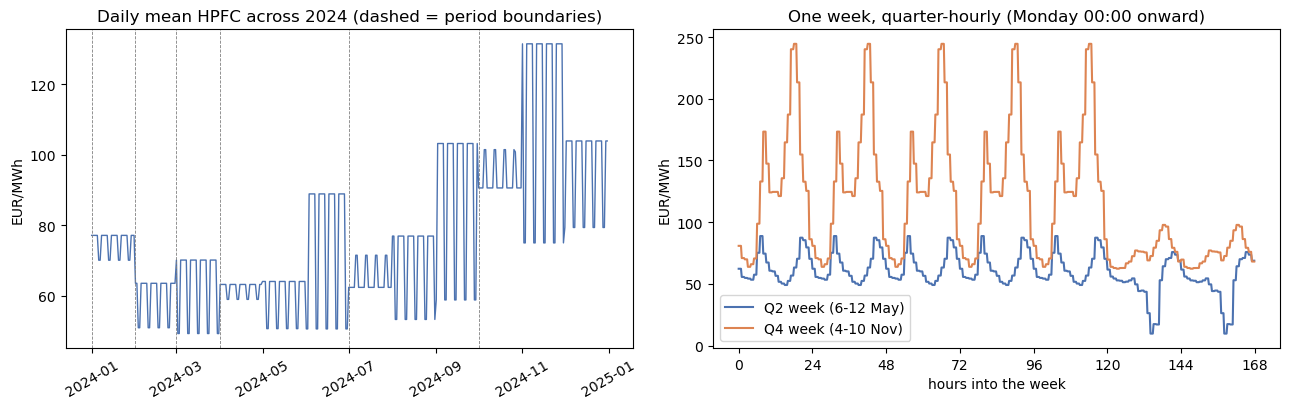

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

# left: daily mean across the whole year - shows the six price "steps" from the periods
daily = shape.set_index("t_local")["hpfc"].resample("D").mean()
axes[0].plot(daily.index, daily.values, color="#4C72B0", lw=1)
for _, r in periods.sort_values("delivery_start").iterrows():
    axes[0].axvline(pd.Timestamp(r["delivery_start"], tz="Europe/Berlin"), color="grey", lw=0.6, ls="--")
axes[0].set_title("Daily mean HPFC across 2024 (dashed = period boundaries)")
axes[0].set_ylabel("EUR/MWh")
axes[0].tick_params(axis="x", rotation=30)

# right: one Q2 week vs. one Q4 week at full quarter-hourly resolution
def week(start_date):
    s = pd.Timestamp(start_date, tz="Europe/Berlin")
    e = s + pd.Timedelta(days=7)
    w = shape[(shape["t_local"] >= s) & (shape["t_local"] < e)].copy()
    w["h"] = (w["t_local"] - s) / pd.Timedelta(hours=1)
    return w

wk_q2, wk_q4 = week("2024-05-06"), week("2024-11-04")   # two Monday-starting weeks
axes[1].plot(wk_q2["h"], wk_q2["hpfc"], color=C_OFF,  label="Q2 week (6-12 May)")
axes[1].plot(wk_q4["h"], wk_q4["hpfc"], color=C_PEAK, label="Q4 week (4-10 Nov)")
axes[1].set_title("One week, quarter-hourly (Monday 00:00 onward)")
axes[1].set_xlabel("hours into the week"); axes[1].set_ylabel("EUR/MWh")
axes[1].set_xticks(range(0, 169, 24))
axes[1].legend()

plt.tight_layout(); plt.show()

**Comment.** The left panel shows six visible price "steps", one per calibration period, with a
sawtooth on top of each step from weekday-vs-weekend daily averages. The right panel makes the
shape within a week explicit: in the Q4 week (orange) every weekday has a sharp evening spike
(up to ~244 EUR/MWh around 18:00) and the weekend sags to its lowest levels of the whole year - a
classic winter Peak premium. In the Q2 week (blue) the pattern is far flatter and can even *dip*
around midday on sunny weekend days (as low as ~10 EUR/MWh) - solar pushes prices down exactly
when Peak-window demand is otherwise highest, which is why Q2's implied Off-Peak price came out
above its Peak price in Section 2.

## 6. Why the HPFC is not a Day-Ahead forecast

The HPFC is useful for **valuation**: it is the cheapest self-consistent way to price any
quarter-hour of 2024 today, because every number in it is anchored to an actually tradable
quote (Base or Peak, GRANULAR or CAL) - two contracts can be compared on the same curve without
ever disagreeing with the market. But it is built from only **six numbers** (one Base and one
Peak price per period) stretched across 35,136 quarter-hours with a **fixed, historical** shape.
It cannot see 2024-specific drivers - a cold snap, a gas-price spike, low wind on a given day - so
it will systematically miss the sharp, weather- and fuel-driven swings that the realised Day-Ahead
price shows (compare Exhibit 3/4). The HPFC answers "what is this quarter-hour worth *today*,
consistent with what the market is willing to pay", not "what will this quarter-hour's price
*actually be*" - that second question is what Stage 4's Day-Ahead shaping and imbalance settlement
address.

## 7. Save the curve

In [8]:
out = shape[["timestamp_utc", "period", "is_peak", "hpfc"]].rename(columns={"hpfc": "hpfc_eur_mwh"})
out.to_csv(f"{DATA}/hpfc.csv", index=False)
print("saved:", f"{DATA}/hpfc.csv", out.shape)
out.head()

saved: ../data/hpfc.csv (35136, 4)


,timestamp_utc,period,is_peak,hpfc_eur_mwh
0,2023-12-31T23:00:00Z,M01,0,59.92
1,2023-12-31T23:15:00Z,M01,0,59.92
2,2023-12-31T23:30:00Z,M01,0,59.92
3,2023-12-31T23:45:00Z,M01,0,59.92
4,2024-01-01T00:00:00Z,M01,0,57.31
